# Compare decoders speed scaling

This notebook will evaluate the speed of a list of decoders given a list of codes and noises.
It will use exactly the same sequence of syndrome such that better comparison could be done even with fewer data.

This notebook only provides basic plotting.

To execute this notebook with a custom code, noise and list of decoders, use
```sh
# srun --time=1-00:00:00 --mem=10G --cpus-per-task=2 \
python3 -m qec_lego_bench notebook-speed-scaling ./dist/speed-scaling.ipynb 'rsc(d=3;p=0.001),rsc(d=5;p=0.001),rsc(d=7;p=0.001)' --decoder 'fb' --decoder 'mwpf(c=0)' --decoder 'mwpf(c=50)' --local-maximum-jobs 8
```

In [1]:
# This cell is tagged `parameters` and will be override by `papermill`

codes: list[str] = ["rsc(d=3,p=0.001)", "rsc(d=5,p=0.001)"]
noises: list[str] = ["none"]
decoders: list[str] = ["mwpf", "mwpf(c=0)", "fb", "fb(max_tree_size=0)"]

min_shots: int = 1000
max_shots: int = 1000000000
min_time: float = 1  # the fastest decoder will run for at least this long (in seconds)


slurm_maximum_jobs: int = 50  # start with a smaller number of workers to avoid resource waste
slurm_cores_per_node: int = 10  # (slurm_maximum_jobs // slurm_cores_per_node) should not exceed 200
slurm_mem_per_job: int = 4  # 4GB per job
slurm_extra: dict = dict(
    walltime = "1-00:00:00",  # adaptively shutdown if no more jobs
    queue = "scavenge",  # use with caution: dask does not seem to handle scavenge workers well
    job_extra_directives = ["--requeue"],  # use with scavenge partition will help spawn scavenged jobs
)

import multiprocessing
local_maximum_jobs: int = multiprocessing.cpu_count()

json_filename: str = None
force_finished: bool = False  # only plot the figure and do not run experiments

repeats: int = 5  # repeat the same experiment for this many times

In [2]:
# Parameters
codes = ["css_rsc(d@99)", "css_rsc(d@81)", "css_rsc(d@65)", "css_rsc(d@53)", "css_rsc(d@43)", "css_rsc(d@35)", "css_rsc(d@27)", "css_rsc(d@23)", "css_rsc(d@19)", "css_rsc(d@15)", "css_rsc(d@13)", "css_rsc(d@9)", "css_rsc(d@7)", "css_rsc(d@5)", "css_rsc(d@3)"]
noises = ["depolarize(p@0.01)"]
decoders = ["mwpf(c@0)", "mwpf(c@50)", "mwpf(c@200)", "fb(max_tree_size@0)", "fb"]
json_filename = "capacity-rsc.json"
min_shots = 1000000
max_shots = 1000000000
min_time = 0
local_maximum_jobs = 6
repeats = 5


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
codes = [code.replace("@", "=").replace(";", ",") for code in codes]
noises = [noise.replace("@", "=").replace(";", ",") for noise in noises]
decoders = [decoder.replace("@", "=").replace(";", ",") for decoder in decoders]


from qec_lego_bench.notebooks.speed_scaling import *

codes, noises = sanity_check_parse_codes_and_noises(codes, noises)

if json_filename is None:
    json_filename = default_json_filename()
print("saving results to:", json_filename)


saving results to: capacity-rsc.json


In [5]:
monte_carlo_function = SpeedScalingMonteCarloFunction(
    decoders=decoders,
    min_shots=min_shots,
    max_shots=max_shots,
    min_time=min_time,
)


jobs = [MonteCarloJob(code=code, noise=noise, repeat=repeat) for code, noise in zip(codes, noises) for repeat in range(repeats)]
# monte_carlo_function(1, codes[0], noises[0], verbose=True)

In [6]:
min_shots_submitter = MinShotsSubmitter(shots=1)

def submitter(executor: MonteCarloJobExecutor) -> list[tuple[MonteCarloJob, int]]:
    return min_shots_submitter(executor)

In [7]:
config = MonteCarloExecutorConfig()
config.max_submitted_job = max(config.max_submitted_job, 3 * slurm_maximum_jobs)
executor = MonteCarloJobExecutor(
    monte_carlo_function,
    jobs,
    config=config,
    filename=json_filename,
    result_type=MultiDecoderLogicalErrorRates,
)

client_connector = SlurmClientConnector(
    slurm_maximum_jobs=slurm_maximum_jobs,
    slurm_cores_per_node=slurm_cores_per_node,
    slurm_mem_per_job=slurm_mem_per_job,
    slurm_extra=slurm_extra,
    local_maximum_jobs=local_maximum_jobs,
)

,Status,JobKey,Job,Finished,Pending,Submitted,0 jobs,Total,Duration,Errors,Discards,Panics,Error Rate
0,finished,d5a1df,"Job(code=css_rsc(d=13), noise=depolarize(p=0.01), repeat=0)",1000000 (100%),0 (0%),0 (0%),0 (0%),1000000,236.9s (3.9min),0,0,0,0.0(0)
1,finished,cc6f8e,"Job(code=css_rsc(d=13), noise=depolarize(p=0.01), repeat=1)",1000000 (100%),0 (0%),0 (0%),0 (0%),1000000,239.1s (4.0min),0,0,0,0.0(0)
2,finished,136314,"Job(code=css_rsc(d=13), noise=depolarize(p=0.01), repeat=2)",1000000 (100%),0 (0%),0 (0%),0 (0%),1000000,236.9s (3.9min),0,0,0,0.0(0)
3,finished,71a007,"Job(code=css_rsc(d=13), noise=depolarize(p=0.01), repeat=3)",1000000 (100%),0 (0%),0 (0%),0 (0%),1000000,237.8s (4.0min),0,0,0,0.0(0)
4,finished,5b8934,"Job(code=css_rsc(d=13), noise=depolarize(p=0.01), repeat=4)",1000000 (100%),0 (0%),0 (0%),0 (0%),1000000,237.6s (4.0min),0,0,0,0.0(0)
5,finished,099528,"Job(code=css_rsc(d=15), noise=depolarize(p=0.01), repeat=0)",1000000 (100%),0 (0%),0 (0%),0 (0%),1000000,283.4s (4.7min),0,0,0,0.0(0)
6,finished,a3648f,"Job(code=css_rsc(d=15), noise=depolarize(p=0.01), repeat=1)",1000000 (100%),0 (0%),0 (0%),0 (0%),1000000,279.9s (4.7min),0,0,0,0.0(0)
7,finished,7caac4,"Job(code=css_rsc(d=15), noise=depolarize(p=0.01), repeat=2)",1000000 (100%),0 (0%),0 (0%),0 (0%),1000000,290.8s (4.8min),0,0,0,0.0(0)
8,finished,7e0ebf,"Job(code=css_rsc(d=15), noise=depolarize(p=0.01), repeat=3)",1000000 (100%),0 (0%),0 (0%),0 (0%),1000000,285.8s (4.8min),0,0,0,0.0(0)
9,finished,f7acdb,"Job(code=css_rsc(d=15), noise=depolarize(p=0.01), repeat=4)",1000000 (100%),0 (0%),0 (0%),0 (0%),1000000,301.8s (5.0min),0,0,0,0.0(0)


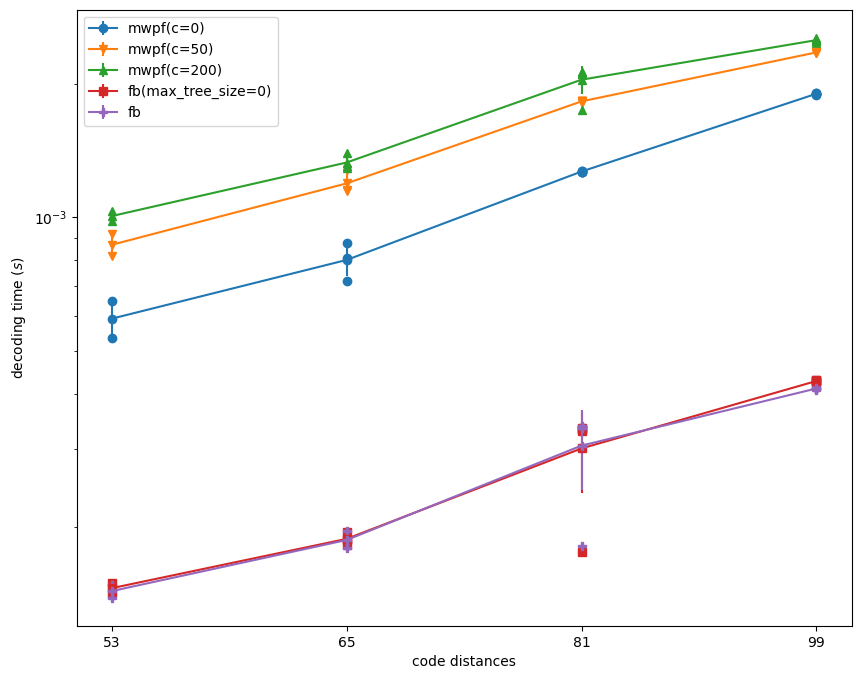

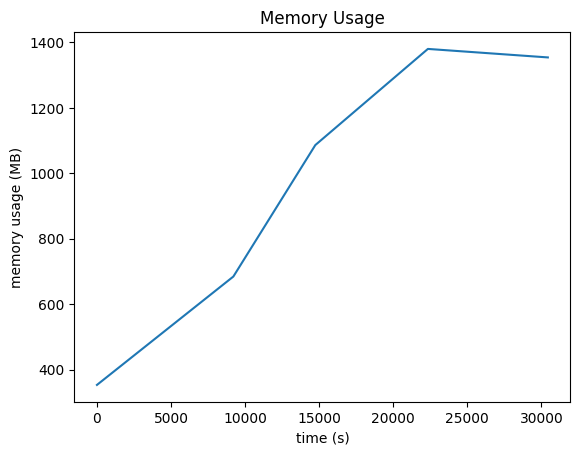

winding up a new client
No module named 'dask_jobqueue'


cluster dashboard link: http://127.0.0.1:8787/status


2025-06-15 23:03:39,940 - distributed.nanny - WARNING - Restarting worker


shutting down the cluster; if this is not desired, set `shutdown_cluster` to `False`


2025-06-15 23:03:39,942 - distributed.nanny - WARNING - Restarting worker


2025-06-15 23:03:39,981 - distributed.nanny - WARNING - Restarting worker


2025-06-15 23:03:39,983 - distributed.nanny - WARNING - Restarting worker


2025-06-15 23:03:40,002 - distributed.nanny - WARNING - Restarting worker


2025-06-15 23:03:40,020 - distributed.nanny - WARNING - Restarting worker


In [8]:
import time  # add some sleep to let them work properly in VScode Jupyter notebook

time.sleep(0.2)
progress_plotter = JobProgressPlotter()
time.sleep(0.2)
speed_scaling_plotter = SpeedScalingPlotter(
    codes=codes, noises=noises, decoders=decoders, repeats=repeats,
)
time.sleep(0.2)
memory_plotter = MemoryUsagePlotter()


def callback(executor: MonteCarloJobExecutor):
    progress_plotter(executor)
    time.sleep(0.1)
    speed_scaling_plotter(executor)
    time.sleep(0.1)
    memory_plotter(executor)
    time.sleep(0.1)


executor.execute(
    client_connector=client_connector,
    submitter=submitter,
    loop_callback=callback,
    shutdown_cluster=True,
    force_finished=force_finished,
)